# GP Regression 

* Constraints: 5% tolerance, using ∆Nd (PD-PI)
* Inputs:
    * ∆lnLWP = GP(PD lnlwp, ∆Nd)
    * ERFaci = GP(∆lnLWP, ∆Nd, da/dlwp)

**revisions version**

In [1]:
import pickle
import importlib

import matplotlib.pyplot as plt
import numpy as np
import multi_ppe_constraint_rev as mpc
import xarray as xr
import statsmodels.api as sm

from sklearn.gaussian_process import kernels,GaussianProcessRegressor
from scipy import stats


In [2]:
# make it stop printing the warnings - bc the ones this raises you can ignore
import warnings
warnings.filterwarnings('ignore')


In [3]:
main_path = "/glade/u/home/jnug/work/multi_PPE_data/"
file_path = main_path + "annual_means/"
pickle_path = main_path + "pickle_jar/"
out_path = pickle_path + "GP_regression_rev/" # not where the odl ones were
fig_path = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"

ppe_list = ["E3SMv3", "GA7.1", "CAM6", "ECHAM6-HAM"]


In [4]:
SEED = 20260120 # random seed for reproducibility
TEST_SPLIT = 0.2 # 80/20 train/test split
N_SAMPLES = 10000 # for final predictions

In [5]:
# define the constraints up here

# 5% for PD LWP, da/dlwp, dnd (PD-PI)

constr_ensn_dict = {}

for ppe in ppe_list:
    
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)

    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err05_dict["delta_Nd_pipd"]["match"]
    tot_ensn = len(err05_dict["LWP_pd"]["match"]) + len(err05_dict["LWP_pd"]["cut"])

    all_meet = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]
    constr_ensn_dict[ppe] = all_meet
    print(f"{ppe} tot={len(all_meet)}; dadlwp cuts {(1-(len(dadlwp_meet)/tot_ensn))*100.:.1f}%, lwp cuts {(1-(len(lwp_meet)/tot_ensn))*100.:.1f}%, ∆Nd PD-PI cuts {(1-(len(dnd_meet)/tot_ensn))*100.:.1f}%")


E3SMv3 tot=19; dadlwp cuts 80.1%, lwp cuts 87.6%, ∆Nd PD-PI cuts 45.4%
GA7.1 tot=12; dadlwp cuts 69.2%, lwp cuts 79.6%, ∆Nd PD-PI cuts 58.8%
CAM6 tot=18; dadlwp cuts 64.1%, lwp cuts 86.6%, ∆Nd PD-PI cuts 24.0%
ECHAM6-HAM tot=32; dadlwp cuts 0.9%, lwp cuts 72.4%, ∆Nd PD-PI cuts 61.5%


#### Kernel list

In [6]:
base_kernels = [
    kernels.RBF(),
    kernels.RationalQuadratic(),
    kernels.Matern(),
    kernels.ConstantKernel(),
    kernels.ExpSineSquared(),
]


In [7]:
# designed for 3 input vars

ekernels_1 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*x + \
              kernels.ConstantKernel()*y + \
              kernels.ConstantKernel
              ()*kernels.Product(kernels.DotProduct(), z) + \
              kernels.WhiteKernel() for x in base_kernels for y in base_kernels for z in base_kernels]

ekernels_2 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*kernels.Product(a, b) + \
              kernels.ConstantKernel()*kernels.Product(c, d) + \
              kernels.WhiteKernel() for a in base_kernels for b in base_kernels for c in base_kernels for d in base_kernels]

ekernels_3 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*x + \
              kernels.ConstantKernel()*kernels.Product(kernels.ExpSineSquared(), kernels.ExpSineSquared()) + \
              kernels.WhiteKernel() for x in base_kernels]

ekernels_4 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), x) + \
              kernels.ConstantKernel()*kernels.Product(kernels.ExpSineSquared(), kernels.ExpSineSquared()) + \
              kernels.WhiteKernel() for x in base_kernels]

ekernels_list = ekernels_1 + ekernels_2 + ekernels_3 + ekernels_4



In [8]:
# designed for 2 input vars

dkernels_1 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*x + \
              kernels.ConstantKernel()*y + \
              kernels.WhiteKernel() for x in base_kernels for y in base_kernels]

dkernels_2 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), x) + \
              kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), y) + \
              kernels.WhiteKernel() for x in base_kernels for y in base_kernels]

dkernels_3 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*x + \
              kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), y) + \
              kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), z) + \
              kernels.WhiteKernel() for x in base_kernels for y in base_kernels  for z in base_kernels]

dkernels_4 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*x + \
              kernels.ConstantKernel()*kernels.Product(y, z) + \
              kernels.WhiteKernel() for x in base_kernels for y in base_kernels for z in base_kernels]

dkernels_5 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*kernels.Product(x, y) + \
              kernels.WhiteKernel() for x in base_kernels for y in base_kernels]

dkernels_6 = [kernels.ConstantKernel() + \
              kernels.ConstantKernel()*x+ \
              kernels.WhiteKernel() for x in base_kernels]

dkernels_list = dkernels_1 + dkernels_2 + dkernels_3 + dkernels_4 + dkernels_5 + dkernels_6



#### Combine PPE data into aggregate arrays

In [15]:
lnlwp_vals = []
dnd_vals = []
dlnlwp_vals = []
erfaci_vals = []
dadlwp_vals = []

# da/dlwp
with open(pickle_path + "PPE_dadlwp_dict.pickle", "rb") as handle:
    dadlwp_dict = pickle.load(handle)

# other data from the .netcdf files
for ppe in ppe_list:
    ds = xr.open_dataset(file_path + f"{ppe}_data_annual_means.nc")
    good_ensn = constr_ensn_dict[ppe]
    ds_good = ds.sel(member=good_ensn)
    print(ppe, len(ds_good.member))

    lnlwp_vals.append(np.log(ds_good["LWP_pd_masked"].values))
    erfaci_vals.append(ds_good["ERFaci"].values)
    dadlwp_vals.append(dadlwp_dict[ppe].sel(member=good_ensn).values)

    dlnlwp_good = (np.log(ds_good["LWP_pd"]) - np.log(ds_good["LWP_pi"]))
    dlnlwp_vals.append(dlnlwp_good.values)
    dnd_good = ds_good["Nd_pd_ocn"] - ds_good["Nd_pi_ocn"]
    dnd_vals.append(dnd_good.values)

lnlwp = np.concatenate(lnlwp_vals)
dnd = np.concatenate(dnd_vals)
dlnlwp = np.concatenate(dlnlwp_vals)
erfaci = np.concatenate(erfaci_vals)
dadlwp = np.concatenate(dadlwp_vals)


E3SMv3 19
GA7.1 12
CAM6 18
ECHAM6-HAM 32


In [16]:
# check - should be 81 for the 5% tolerances and ∆Nd (PD-PI)
print([len(x) for x in [lnlwp, dnd, dlnlwp, erfaci, dadlwp]])

[81, 81, 81, 81, 81]


#### Split into training & testing datasets
* ∆lnLWP = GP(lnLWP, ∆Nd)
* ERFaci = GP(∆lnLWP, ∆Nd, da/dlwp)

In [18]:
seed = SEED
test_split = TEST_SPLIT

In [19]:
# get indices for training & testing data
n_test = int(np.round(len(lnlwp)*test_split))
pct_test = n_test/len(lnlwp)
member_inds = np.arange(len(lnlwp))
np.random.seed(seed)
ind = np.random.choice(member_inds, replace=False, size=n_test)
indtest = np.in1d(member_inds, ind)
indtrain = indtest==False


In [20]:
# check the length is right
indtest.sum(), indtrain.sum()

(16, 65)

In [21]:
# training data
lnlwp_train = lnlwp[indtrain]
dnd_train = dnd[indtrain]
dlnlwp_train = dlnlwp[indtrain]
dadlwp_train = dadlwp[indtrain]
erfaci_train = erfaci[indtrain]

# testing data
lnlwp_test = lnlwp[indtest]
dnd_test = dnd[indtest]
dlnlwp_test = dlnlwp[indtest]
dadlwp_test = dadlwp[indtest]
erfaci_test = erfaci[indtest]


In [22]:
# ∆lnLWP inputs
xd_train = np.column_stack((lnlwp_train, dnd_train))
xd_test = np.column_stack((lnlwp_test, dnd_test))
yd_train = dlnlwp_train
yd_test = dlnlwp_test
dtraining = [xd_train, yd_train]
dtesting = [xd_test, yd_test]


In [23]:
# ERFaci inputs
xe_train = np.column_stack((dlnlwp_train, dadlwp_train, dnd_train))
xe_test = np.column_stack((dlnlwp_test, dadlwp_test, dnd_test))
ye_train = erfaci_train
ye_test = erfaci_test
etraining = [xe_train, ye_train]
etesting = [xe_test, ye_test]


#### Find a good kernel

##### ∆lnLWP

In [22]:
good_slope = 0.4
good_r2 = 0.4
good_rmse = 0.045
good_pct_bad = 5

varlab = r"$\Delta$lnLWP"

xtrain = xd_train
xtest = xd_test
ytrain = yd_train
ytest = yd_test


In [25]:
test1 = kernels.ConstantKernel() + \
        kernels.ConstantKernel()*kernels.Product(kernels.ExpSineSquared(), kernels.RationalQuadratic()) + \
        kernels.ConstantKernel()*kernels.Product(kernels.Matern(), kernels.ExpSineSquared()) + \
        kernels.WhiteKernel()

kernels_list = [*dkernels_list, *ekernels_list]


1**2 + 1**2 * RBF(length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1)
0.0


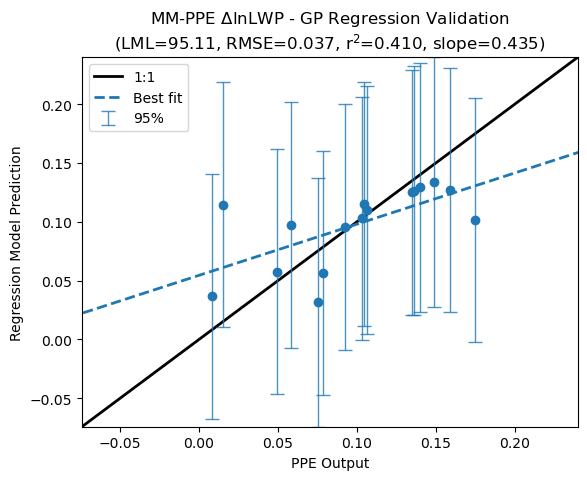

1**2 + 1**2 * Matern(length_scale=1, nu=1.5) * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * RBF(length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


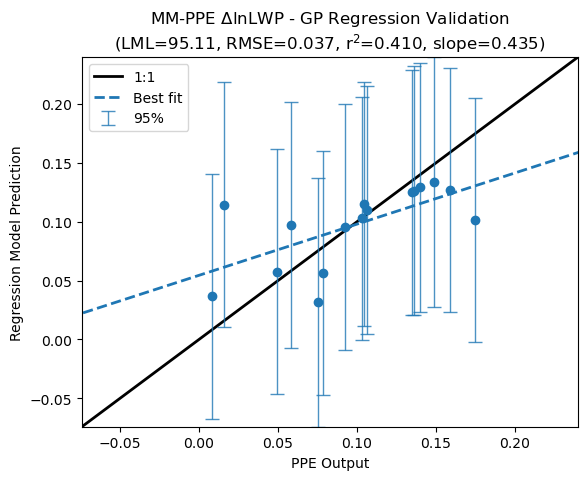

1**2 + 1**2 * Matern(length_scale=1, nu=1.5) * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RBF(length_scale=1) + WhiteKernel(noise_level=1)
0.0


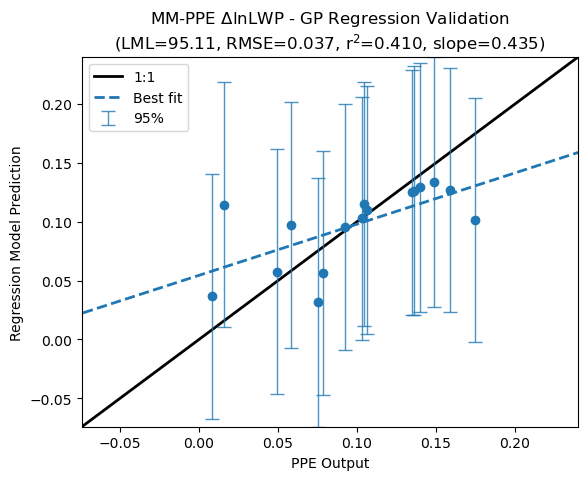

1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RBF(length_scale=1) + 1**2 * Matern(length_scale=1, nu=1.5) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


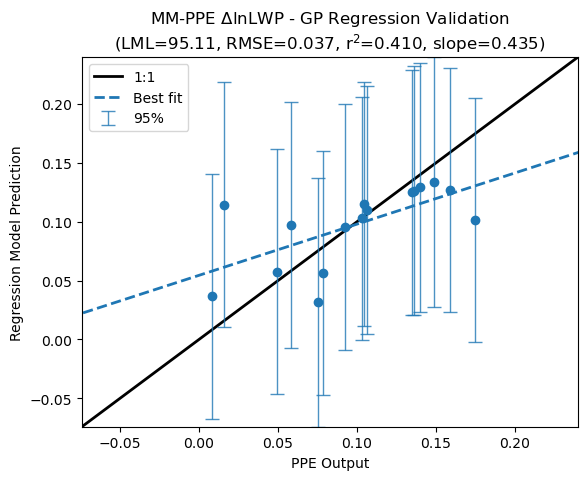

1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RBF(length_scale=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1)
0.0


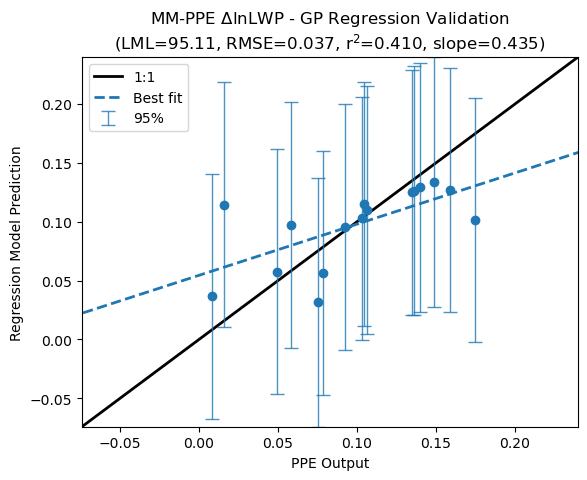

1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RationalQuadratic(alpha=1, length_scale=1) + 1**2 * Matern(length_scale=1, nu=1.5) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


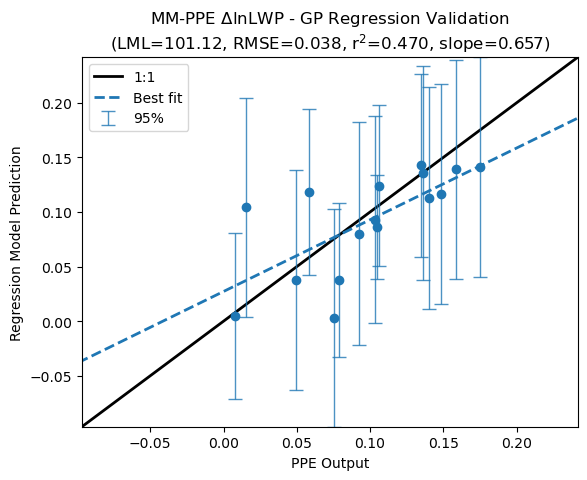

1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * Matern(length_scale=1, nu=1.5) + 1**2 * RBF(length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


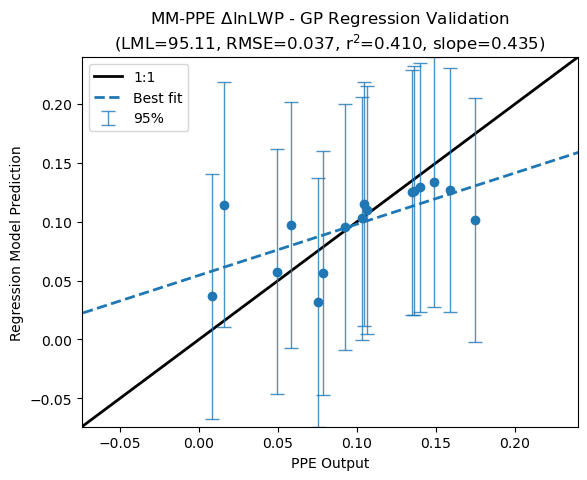

1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * Matern(length_scale=1, nu=1.5) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)
0.0


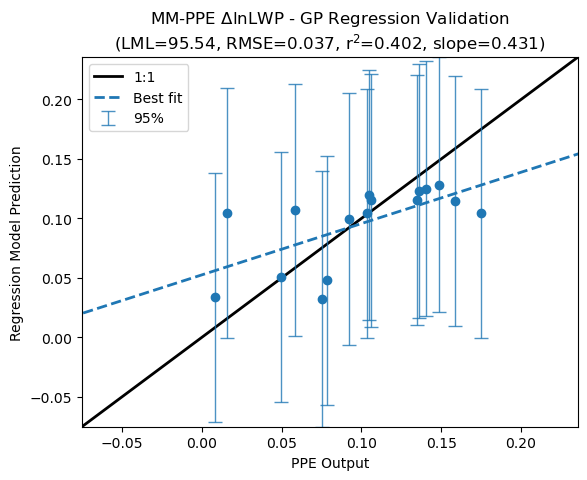

CPU times: user 12min 12s, sys: 115 ms, total: 12min 12s
Wall time: 13min 15s


In [24]:
%%time 

for kernel in kernels_list:

    # fit & predict
    gp = GaussianProcessRegressor(kernel, alpha=1e-10,
                                 n_restarts_optimizer=10, normalize_y=False,
                                 random_state=seed, copy_X_train=False)
    gp.fit(xtrain, ytrain)
    pred_test, sd_test = gp.predict(xtest, return_std=True)
    lml = gp.log_marginal_likelihood(gp.kernel_.theta)
    rmse = sm.tools.eval_measures.rmse(ytest, pred_test) 

    # linear reg to see how close to 1-1
    X = sm.add_constant(ytest)
    model = sm.OLS(pred_test, X)
    results = model.fit()

    # get 95% conf intervals for each prediction and see how many don't include 1-1
    # based off of ESEm prediction_within_ci()
    lower, upper = stats.norm.interval(0.95, loc=pred_test, scale=sd_test)
    within_95_ci = (upper > ytest) & (lower < ytest)
    valid_points = ytest.shape[0]
    pct_bad = ((~within_95_ci).sum()/valid_points)*100.
    
    # show plot only if it's good
    slope = results.params[1]
    r2 = results.rsquared

    if slope >= good_slope and r2 >= good_r2 and rmse < good_rmse and pct_bad < good_pct_bad:
        print(kernel)
        print(pct_bad)
        
        col = ["C0" for b in within_95_ci]
        dotcol = ["C0" for b in within_95_ci]
        fig, ax = plt.subplots()
        ax.axline([0, 0], slope=1, color="k", label="1:1", zorder=0, lw=2)

        for i in range(len(ytest)):
            if i == 1:
                lab = "95%"
            else:
                lab = None
            error = pred_test[i] - lower[i]
            ax.errorbar(ytest[i], pred_test[i], yerr=error, fmt="none", capsize=5, color=col[i], label=lab,
                        lw=1, alpha=0.8)
            ax.scatter(ytest[i], pred_test[i], color=dotcol[i], zorder=100)

        minx = ytest.min() 
        maxx = ytest.max()
        miny = lower.min() 
        maxy = upper.max() 
        ax_lims = [np.nanmin((minx, miny)), np.nanmax((maxx, maxy))]
        ax.set_xlim(ax_lims)
        ax.set_ylim(ax_lims)
        xspan = np.linspace(-4, 4, 40)
        ax.plot(xspan, xspan*slope+results.params[0], color="C0", label="Best fit", lw=2, ls="--")
        ax.legend(loc="upper left")
        ax.set_title(f"MM-PPE {varlab} - GP Regression Validation\n(LML={lml:.2f}, RMSE={rmse:.3f}, r$^2$={r2:.3f}, slope={slope:.3f})")
        ax.set_xlabel(f"PPE Output")
        ax.set_ylabel("Regression Model Prediction")
        plt.show()   


##### intentionally worse ∆lnLWP
Find a kernel that results in a less skilled model to use for reviewer response

In [20]:
varlab = r"$\Delta$lnLWP"

xtrain = xd_train
xtest = xd_test
ytrain = yd_train
ytest = yd_test


In [27]:


kernels_list = ekernels_list #dkernels_list


1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * Matern(length_scale=1, nu=1.5) + 1**2 * DotProduct(sigma_0=1) * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1)
0.0


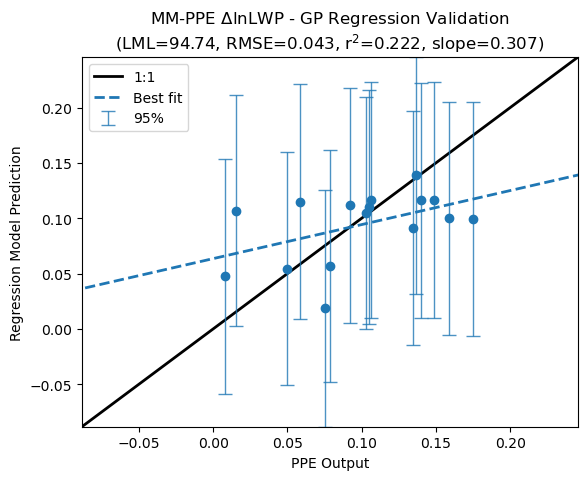

1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * 1**2 + 1**2 * DotProduct(sigma_0=1) * 1**2 + WhiteKernel(noise_level=1)
0.0


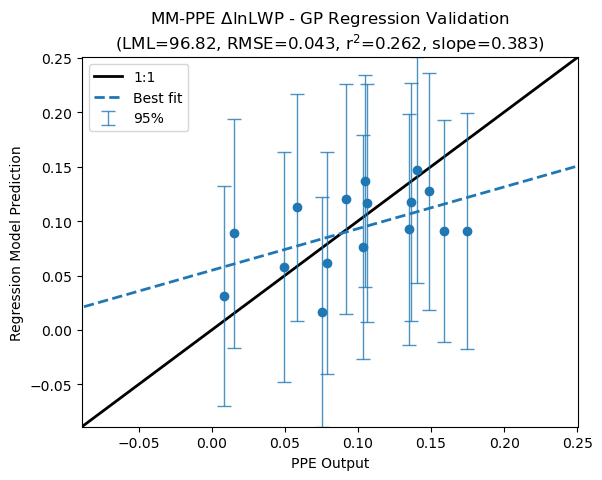

1**2 + 1**2 * RBF(length_scale=1) * RationalQuadratic(alpha=1, length_scale=1) + 1**2 * RationalQuadratic(alpha=1, length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


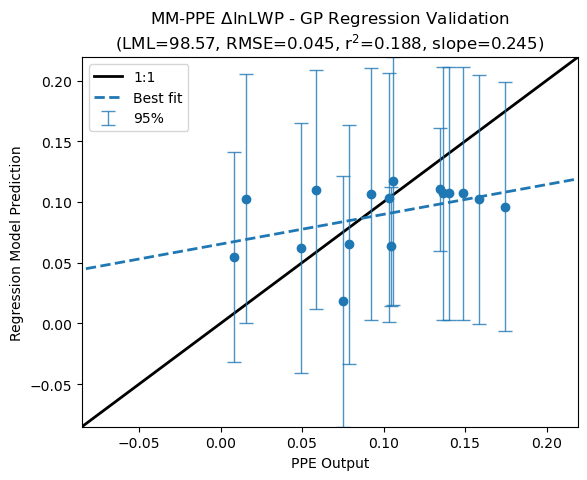

1**2 + 1**2 * RationalQuadratic(alpha=1, length_scale=1) * RationalQuadratic(alpha=1, length_scale=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


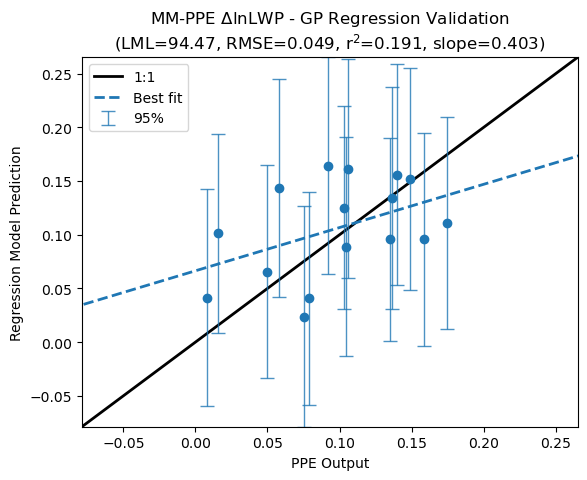

1**2 + 1**2 * RationalQuadratic(alpha=1, length_scale=1) * Matern(length_scale=1, nu=1.5) + 1**2 * RBF(length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


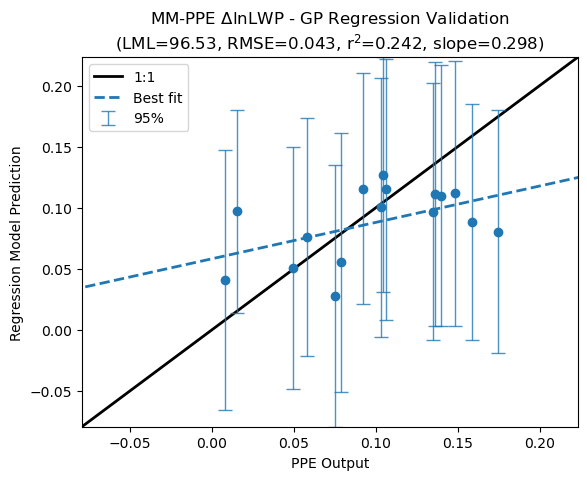

1**2 + 1**2 * RationalQuadratic(alpha=1, length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * RBF(length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


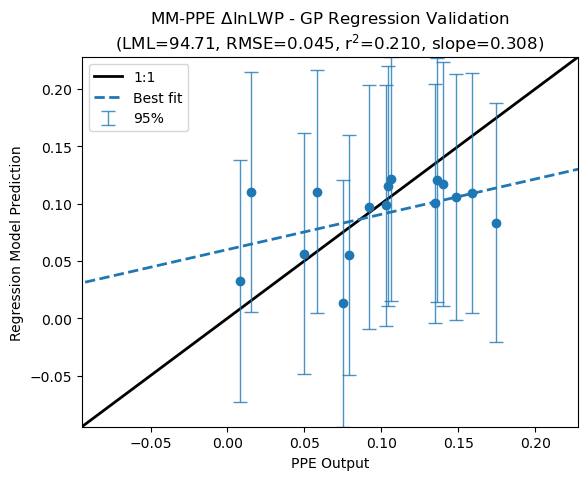

1**2 + 1**2 * RationalQuadratic(alpha=1, length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RBF(length_scale=1) + WhiteKernel(noise_level=1)
0.0


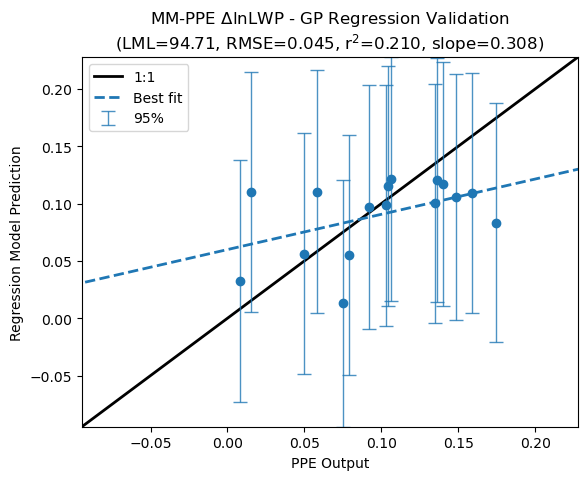

1**2 + 1**2 * RationalQuadratic(alpha=1, length_scale=1) * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)
0.0


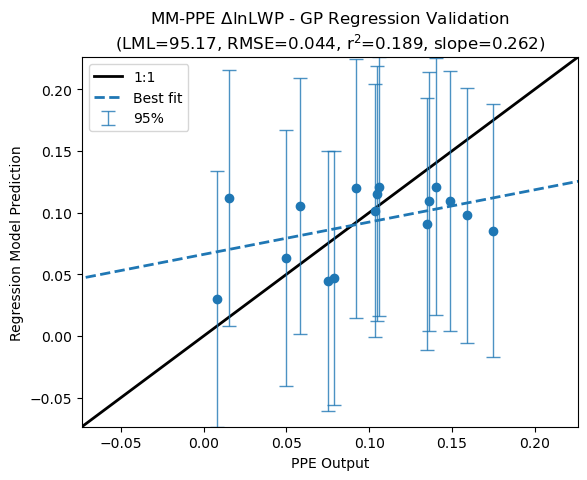

KeyboardInterrupt: 

KeyboardInterrupt: 

In [28]:
%%time 

for kernel in kernels_list:

    # fit & predict
    gp = GaussianProcessRegressor(kernel, alpha=1e-10,
                                 n_restarts_optimizer=10, normalize_y=False,
                                 random_state=seed, copy_X_train=False)
    gp.fit(xtrain, ytrain)
    pred_test, sd_test = gp.predict(xtest, return_std=True)
    lml = gp.log_marginal_likelihood(gp.kernel_.theta)
    rmse = sm.tools.eval_measures.rmse(ytest, pred_test) 

    # linear reg to see how close to 1-1
    X = sm.add_constant(ytest)
    model = sm.OLS(pred_test, X)
    results = model.fit()

    # get 95% conf intervals for each prediction and see how many don't include 1-1
    # based off of ESEm prediction_within_ci()
    lower, upper = stats.norm.interval(0.95, loc=pred_test, scale=sd_test)
    within_95_ci = (upper > ytest) & (lower < ytest)
    valid_points = ytest.shape[0]
    pct_bad = ((~within_95_ci).sum()/valid_points)*100.
    
    # show plot only if it's "BAD" (but still valid)
    slope = results.params[1]
    r2 = results.rsquared

    # if slope < 0.3 and slope >= 0.1 and r2 < 0.3 and rmse > 0.042 and pct_bad < 5:
    if rmse >= 0.043 and slope > 0 and pct_bad < 5:
        print(kernel)
        print(pct_bad)
        
        col = ["C0" for b in within_95_ci]
        dotcol = ["C0" for b in within_95_ci]
        fig, ax = plt.subplots()
        ax.axline([0, 0], slope=1, color="k", label="1:1", zorder=0, lw=2)

        for i in range(len(ytest)):
            if i == 1:
                lab = "95%"
            else:
                lab = None
            error = pred_test[i] - lower[i]
            ax.errorbar(ytest[i], pred_test[i], yerr=error, fmt="none", capsize=5, color=col[i], label=lab,
                        lw=1, alpha=0.8)
            ax.scatter(ytest[i], pred_test[i], color=dotcol[i], zorder=100)

        minx = ytest.min() 
        maxx = ytest.max()
        miny = lower.min() 
        maxy = upper.max() 
        ax_lims = [np.nanmin((minx, miny)), np.nanmax((maxx, maxy))]
        ax.set_xlim(ax_lims)
        ax.set_ylim(ax_lims)
        xspan = np.linspace(-4, 4, 40)
        ax.plot(xspan, xspan*slope+results.params[0], color="C0", label="Best fit", lw=2, ls="--")
        ax.legend(loc="upper left")
        ax.set_title(f"MM-PPE {varlab} - GP Regression Validation\n(LML={lml:.2f}, RMSE={rmse:.3f}, r$^2$={r2:.3f}, slope={slope:.3f})")
        ax.set_xlabel(f"PPE Output")
        ax.set_ylabel("Regression Model Prediction")
        plt.show()   


##### ERFaci

In [20]:
good_slope = 0.75
good_r2 = 0.75
good_rmse = 0.4

good_pctbad = 5

varlab = "ERFaci"

xtrain = xe_train
xtest = xe_test
ytrain = ye_train
ytest = ye_test


In [21]:

test2 = kernels.ConstantKernel() + \
        kernels.ConstantKernel()*kernels.ExpSineSquared() +\
        kernels.ConstantKernel()*kernels.ExpSineSquared() +\
        kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), kernels.ConstantKernel()) + \
        kernels.WhiteKernel()

kernels_list = [*ekernels_list, *dkernels_list]


1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * DotProduct(sigma_0=1) * 1**2 + WhiteKernel(noise_level=1)
0.0


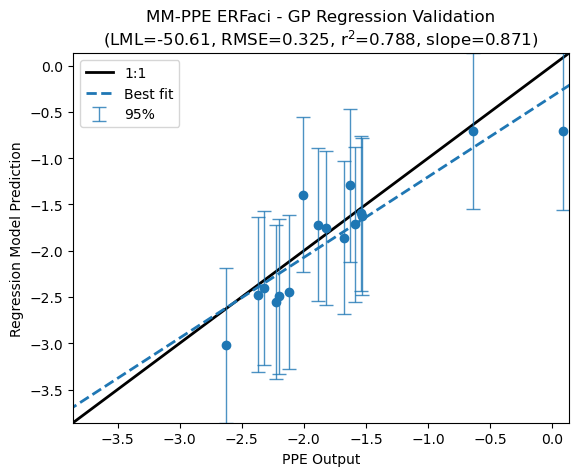

CPU times: user 14min 12s, sys: 151 ms, total: 14min 12s
Wall time: 15min 26s


In [22]:
%%time 

for kernel in kernels_list:

    # fit & predict
    gp = GaussianProcessRegressor(kernel, alpha=1e-10,
                                 n_restarts_optimizer=10, normalize_y=False,
                                 random_state=seed, copy_X_train=False)
    gp.fit(xtrain, ytrain)
    pred_test, sd_test = gp.predict(xtest, return_std=True)
    lml = gp.log_marginal_likelihood(gp.kernel_.theta)
    rmse = sm.tools.eval_measures.rmse(ytest, pred_test) 

    # linear reg to see how close to 1-1
    X = sm.add_constant(ytest)
    model = sm.OLS(pred_test, X)
    results = model.fit()

    # get 95% conf intervals for each prediction and see how many don't include 1-1
    # based off of ESEm prediction_within_ci()
    lower, upper = stats.norm.interval(0.95, loc=pred_test, scale=sd_test)
    within_95_ci = (upper > ytest) & (lower < ytest)
    valid_points = ytest.shape[0]
    pct_bad = ((~within_95_ci).sum()/valid_points)*100.
    
    # show plot only if it's good
    slope = results.params[1]
    r2 = results.rsquared

    if slope >= good_slope and r2 >= good_r2 and rmse < good_rmse and pct_bad <= good_pctbad:
        print(kernel)
        print(pct_bad)
        
        col = ["C0" for b in within_95_ci]
        dotcol = ["C0" for b in within_95_ci]
        fig, ax = plt.subplots()
        ax.axline([0, 0], slope=1, color="k", label="1:1", zorder=0, lw=2)

        for i in range(len(ytest)):
            if i == 1:
                lab = "95%"
            else:
                lab = None
            error = pred_test[i] - lower[i]
            ax.errorbar(ytest[i], pred_test[i], yerr=error, fmt="none", capsize=5, color=col[i], label=lab,
                        lw=1, alpha=0.8)
            ax.scatter(ytest[i], pred_test[i], color=dotcol[i], zorder=100)

        minx = ytest.min() 
        maxx = ytest.max()
        miny = lower.min() 
        maxy = upper.max() 
        ax_lims = [np.nanmin((minx, miny)), np.nanmax((maxx, maxy))]
        ax.set_xlim(ax_lims)
        ax.set_ylim(ax_lims)
        xspan = np.linspace(-4, 4, 40)
        ax.plot(xspan, xspan*slope+results.params[0], color="C0", label="Best fit", lw=2, ls="--")
        ax.legend(loc="upper left")
        ax.set_title(f"MM-PPE {varlab} - GP Regression Validation\n(LML={lml:.2f}, RMSE={rmse:.3f}, r$^2$={r2:.3f}, slope={slope:.3f})")
        ax.set_xlabel(f"PPE Output")
        ax.set_ylabel("Regression Model Prediction")
        plt.show()   


#### Save trained models w/good kernels and make predictions

In [6]:
print(mpc.PD_LWP)
print(mpc.DELTA_ND)
print(mpc.DADLWP)


[65, 80]
[8, 24]
[1.7, 2.1]


In [7]:
def conf_int(gp, input, return_pred_mean=True):
    """ 
    Get the 95% and 90% (i.e., 5-95%) confidence intervals using a 
    trained GP regression model and idealized inputs. 
    """
    pred_mean, pred_sigma = gp.predict(input, return_std=True)
    
    min95 = pred_mean.mean() - 1.96*pred_sigma.mean()
    max95 = pred_mean.mean() + 1.96*pred_sigma.mean()

    min90 = pred_mean.mean() - 1.64*pred_sigma.mean()
    max90 = pred_mean.mean() + 1.64*pred_sigma.mean()
    
    ci = {"95%": [min95, max95], "90%": [min90, max90]}

    if return_pred_mean:
        return ci, pred_mean 
    else:
        return ci
    

In [8]:
def get_gauss95(xmin, xmax, n_samples=N_SAMPLES, seed=SEED):
    """ 
    Returns an array of length n_samples with random samples
    within a 95% confidence interval [xmin, xmax] of a 
    normal distribution
    """
    mean = 0.5*(xmin + xmax)
    std = (xmax - mean)/1.96
    rng = np.random.default_rng(seed=seed)
    gauss = rng.normal(loc=mean, scale=std, size=int(n_samples*1/.95))
    gauss_95 = gauss[(gauss <= xmax) & (gauss >= xmin)]

    return gauss_95


##### Re-train the models with the selected kernels and save

In [24]:
good_dlnlwp_kernel = kernels.ConstantKernel() + \
                    kernels.ConstantKernel()*kernels.Product(kernels.ExpSineSquared(), kernels.RationalQuadratic()) + \
                    kernels.ConstantKernel()*kernels.Product(kernels.Matern(), kernels.ExpSineSquared()) + \
                    kernels.WhiteKernel()

good_erfaci_kernel = kernels.ConstantKernel() + \
                    kernels.ConstantKernel()*kernels.ExpSineSquared() +\
                    kernels.ConstantKernel()*kernels.ExpSineSquared() +\
                    kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), kernels.ConstantKernel()) + \
                    kernels.WhiteKernel()


1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) * RationalQuadratic(alpha=1, length_scale=1) + 1**2 * Matern(length_scale=1, nu=1.5) * ExpSineSquared(length_scale=1, periodicity=1) + WhiteKernel(noise_level=1)
0.0


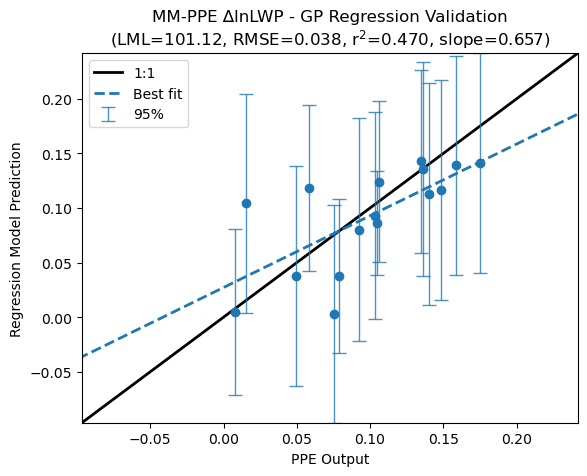

In [22]:
# fit dlnlwp
gp_dlnlwp = GaussianProcessRegressor(good_dlnlwp_kernel, alpha=1e-10,
                              n_restarts_optimizer=10, normalize_y=False,
                              random_state=seed, copy_X_train=False)
gp_dlnlwp.fit(xd_train, yd_train)
pred_test, sd_test = gp_dlnlwp.predict(xd_test, return_std=True)
lml = gp_dlnlwp.log_marginal_likelihood(gp_dlnlwp.kernel_.theta)
rmse = sm.tools.eval_measures.rmse(yd_test, pred_test) 

# linear reg to see how close to 1-1
X = sm.add_constant(yd_test)
model = sm.OLS(pred_test, X)
results = model.fit()

# get 95% conf intervals for each prediction and see how many don't include 1-1
# based off of ESEm prediction_within_ci()
lower, upper = stats.norm.interval(0.95, loc=pred_test, scale=sd_test)
within_95_ci = (upper > yd_test) & (lower < yd_test)
valid_points = yd_test.shape[0]
pct_bad = ((~within_95_ci).sum()/valid_points)*100.

################
# --- plot --- #
################
slope = results.params[1]
r2 = results.rsquared

print(good_dlnlwp_kernel)
print(pct_bad)

col = ["C0" for b in within_95_ci]
dotcol = ["C0" for b in within_95_ci]
fig, ax = plt.subplots()
ax.axline([0, 0], slope=1, color="k", label="1:1", zorder=0, lw=2)

for i in range(len(yd_test)):
    if i == 1:
        lab = "95%"
    else:
        lab = None
    error = pred_test[i] - lower[i]
    ax.errorbar(yd_test[i], pred_test[i], yerr=error, fmt="none", capsize=5, color=col[i], label=lab,
                lw=1, alpha=0.8)
    ax.scatter(yd_test[i], pred_test[i], color=dotcol[i], zorder=100)

minx = yd_test.min() 
maxx = yd_test.max()
miny = lower.min() 
maxy = upper.max() 
ax_lims = [np.nanmin((minx, miny)), np.nanmax((maxx, maxy))]
ax.set_xlim(ax_lims)
ax.set_ylim(ax_lims)
xspan = np.linspace(-4, 4, 40)
ax.plot(xspan, xspan*slope+results.params[0], color="C0", label="Best fit", lw=2, ls="--")
ax.legend(loc="upper left")
ax.set_title(f"MM-PPE ∆lnLWP - GP Regression Validation\n(LML={lml:.2f}, RMSE={rmse:.3f}, r$^2$={r2:.3f}, slope={slope:.3f})")
ax.set_xlabel(f"PPE Output")
ax.set_ylabel("Regression Model Prediction")

# save it 
plt.savefig(fig_path + "dlnlwp_GPR_validation.png", dpi=300, bbox_inches="tight")

plt.show()   


1**2 + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * ExpSineSquared(length_scale=1, periodicity=1) + 1**2 * DotProduct(sigma_0=1) * 1**2 + WhiteKernel(noise_level=1)
0.0


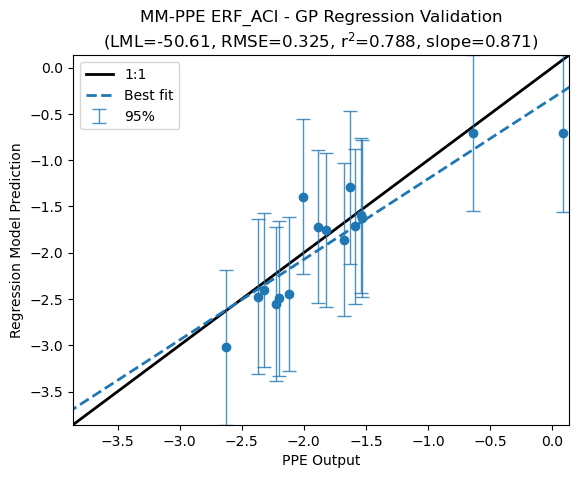

In [25]:
# fit ERFaci
gp_erfaci = GaussianProcessRegressor(good_erfaci_kernel, alpha=1e-10,
                              n_restarts_optimizer=10, normalize_y=False,
                              random_state=seed, copy_X_train=False)
gp_erfaci.fit(xe_train, ye_train)
pred_test, sd_test = gp_erfaci.predict(xe_test, return_std=True)
lml = gp_erfaci.log_marginal_likelihood(gp_erfaci.kernel_.theta)
rmse = sm.tools.eval_measures.rmse(ye_test, pred_test) 

# linear reg to see how close to 1-1
X = sm.add_constant(ye_test)
model = sm.OLS(pred_test, X)
results = model.fit()

# get 95% conf intervals for each prediction and see how many don't include 1-1
# based off of ESEm prediction_within_ci()
lower, upper = stats.norm.interval(0.95, loc=pred_test, scale=sd_test)
within_95_ci = (upper > ye_test) & (lower < ye_test)
valid_points = ye_test.shape[0]
pct_bad = ((~within_95_ci).sum()/valid_points)*100.

################
# --- plot --- #
################
slope = results.params[1]
r2 = results.rsquared

print(good_erfaci_kernel)
print(pct_bad)

col = ["C0" for b in within_95_ci]
dotcol = ["C0" for b in within_95_ci]
fig, ax = plt.subplots()
ax.axline([0, 0], slope=1, color="k", label="1:1", zorder=0, lw=2)

for i in range(len(ye_test)):
    if i == 1:
        lab = "95%"
    else:
        lab = None
    error = pred_test[i] - lower[i]
    ax.errorbar(ye_test[i], pred_test[i], yerr=error, fmt="none", capsize=5, color=col[i], label=lab,
                lw=1, alpha=0.8)
    ax.scatter(ye_test[i], pred_test[i], color=dotcol[i], zorder=100)

minx = ye_test.min() 
maxx = ye_test.max()
miny = lower.min() 
maxy = upper.max() 
ax_lims = [np.nanmin((minx, miny)), np.nanmax((maxx, maxy))]
ax.set_xlim(ax_lims)
ax.set_ylim(ax_lims)
xspan = np.linspace(-4, 4, 40)
ax.plot(xspan, xspan*slope+results.params[0], color="C0", label="Best fit", lw=2, ls="--")
ax.legend(loc="upper left")
ax.set_title(f"MM-PPE ERF_ACI - GP Regression Validation\n(LML={lml:.2f}, RMSE={rmse:.3f}, r$^2$={r2:.3f}, slope={slope:.3f})")
ax.set_xlabel(f"PPE Output")
ax.set_ylabel("Regression Model Prediction")

# save it 
plt.savefig(fig_path + "ERFaci_GPR_validation.png", dpi=300, bbox_inches="tight")

plt.show()   


In [28]:
# save the models & kernels & train/test data

with open(out_path + "MM-PPE_dlnlwp_GPR_model_final.pickle", "wb") as handle:
    pickle.dump(gp_dlnlwp, handle)
with open(out_path + "MM-PPE_dlnlwp_GPR_kernel_final.pickle", "wb") as handle:
    pickle.dump(good_dlnlwp_kernel, handle)
with open(out_path + "MM-PPE_dlnlwp_GPR_kernel_train_test.pickle", "wb") as handle:
    pickle.dump({"training": [xd_train, yd_train], "testing": [xd_test, yd_test]}, handle)

with open(out_path + "MM-PPE_ERFaci_GPR_model_final.pickle", "wb") as handle:
    pickle.dump(gp_erfaci, handle)
with open(out_path + "MM-PPE_ERFaci_GPR_kernel_final.pickle", "wb") as handle:
    pickle.dump(good_erfaci_kernel, handle)
with open(out_path + "MM-PPE_ERFaci_GPR_kernel_train_test.pickle", "wb") as handle:
    pickle.dump({"training": [xe_train, ye_train], "testing": [xe_test, ye_test]}, handle)


##### Read in the trained models and use to predict

In [9]:
with open(out_path + "MM-PPE_dlnlwp_GPR_model_final.pickle", "rb") as handle:
    gp_dlnlwp_trained = pickle.load(handle)
    
with open(out_path + "MM-PPE_ERFaci_GPR_model_final.pickle", "rb") as handle:
    gp_erfaci_trained = pickle.load(handle)
    

In [10]:
# idealized inputs for ∆lnLWP

lnlwp_gauss = get_gauss95(np.log(mpc.PD_LWP[0]), np.log(mpc.PD_LWP[1]))
dnd_gauss = get_gauss95(mpc.DELTA_ND[0], mpc.DELTA_ND[1])

lenmin = min(len(lnlwp_gauss), len(dnd_gauss))
dinput = np.column_stack((lnlwp_gauss[:lenmin], dnd_gauss[:lenmin]))


In [12]:
ci_dict_dlnlwp, pred_mean_dlnlwp = conf_int(gp_dlnlwp_trained, dinput)

print("MM-PPE ∆lnLWP")
print(f"90%: {ci_dict_dlnlwp["90%"][0]:.3f} to {ci_dict_dlnlwp["90%"][1]:.3f}")
print(f"95%: {ci_dict_dlnlwp["95%"][0]:.3f} to {ci_dict_dlnlwp["95%"][1]:.3f}")


MM-PPE ∆lnLWP
90%: -0.003 to 0.144
95%: -0.017 to 0.158


In [13]:
# idealized inputs for ERFaci
# (∆lnLWP comes from the GPR prediction 95% CI)

dnd_gauss = get_gauss95(mpc.DELTA_ND[0], mpc.DELTA_ND[1])
dadlwp_gauss = get_gauss95(mpc.DADLWP[0], mpc.DADLWP[1])
dlnlwp_gauss = get_gauss95(ci_dict_dlnlwp["95%"][0], ci_dict_dlnlwp["95%"][1])

lenmin = min(len(dlnlwp_gauss), len(dadlwp_gauss), len(dnd_gauss))
einput = np.column_stack((dlnlwp_gauss[:lenmin], dadlwp_gauss[:lenmin], dnd_gauss[:lenmin]))


In [14]:
ci_dict_erfaci, pred_mean_erfaci = conf_int(gp_erfaci_trained, einput)

print("MM-PPE ERFaci")
print(f"90%: {ci_dict_erfaci["90%"][0]:.3f} to {ci_dict_erfaci["90%"][1]:.3f}")
print(f"95%: {ci_dict_erfaci["95%"][0]:.3f} to {ci_dict_erfaci["95%"][1]:.3f}")


MM-PPE ERFaci
90%: -2.106 to -0.709
95%: -2.242 to -0.573


In [36]:
# inputs for the predictions
with open(out_path + "MM-PPE_dlnlwp_GPR_pred_input_final.pickle", "wb") as handle:
    pickle.dump(dinput, handle)
with open(out_path + "MM-PPE_ERFaci_GPR_pred_input_final.pickle", "wb") as handle:
    pickle.dump(einput, handle)


In [37]:
# FINAL credible intervals
with open(out_path + "MM-PPE_dlnlwp_CI_final.pickle", "wb") as handle:
    pickle.dump(ci_dict_dlnlwp, handle)
with open(out_path + "MM-PPE_ERFaci_CI_final.pickle", "wb") as handle:
    pickle.dump(ci_dict_erfaci, handle)



##### Worse ∆lnLWP model for reviewer response

In [32]:
bad_dlnlwp_kernel1 = kernels.ConstantKernel() + \
                     kernels.ConstantKernel()*kernels.Matern() + \
                     kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), kernels.ExpSineSquared()) + \
                     kernels.ConstantKernel()*kernels.Product(kernels.DotProduct(), kernels.RBF()) + \
                     kernels.WhiteKernel()

bad_dlnlwp_kernel2 = kernels.ConstantKernel() + \
                     kernels.ConstantKernel()*kernels.Product(kernels.RBF(), kernels.RationalQuadratic()) + \
                     kernels.ConstantKernel()*kernels.Product(kernels.RationalQuadratic(), kernels.ExpSineSquared()) + \
                     kernels.WhiteKernel()

bad_dlnlwp_kernel3 = kernels.ConstantKernel() + \
                     kernels.ConstantKernel()*kernels.Product(kernels.RationalQuadratic(), kernels.ExpSineSquared()) + \
                     kernels.ConstantKernel()*kernels.Product(kernels.ExpSineSquared(), kernels.RationalQuadratic()) + \
                     kernels.WhiteKernel()


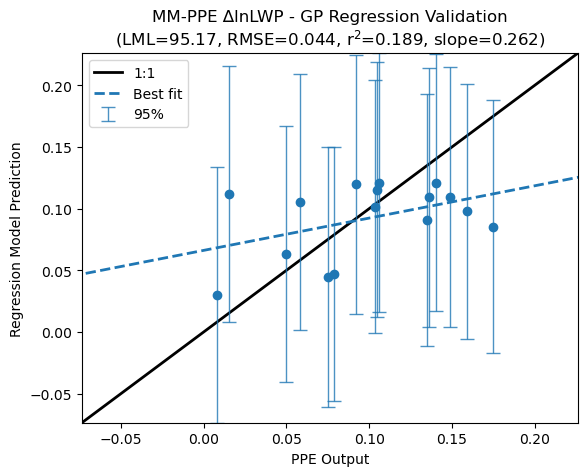

In [51]:
# fit dlnlwp
gp_dlnlwp_bad = GaussianProcessRegressor(bad_dlnlwp_kernel3, alpha=1e-10,
                              n_restarts_optimizer=10, normalize_y=False,
                              random_state=seed, copy_X_train=False)
gp_dlnlwp_bad.fit(xd_train, yd_train)
pred_test, sd_test = gp_dlnlwp_bad.predict(xd_test, return_std=True)
lml = gp_dlnlwp_bad.log_marginal_likelihood(gp_dlnlwp_bad.kernel_.theta)
rmse = sm.tools.eval_measures.rmse(yd_test, pred_test) 

# linear reg to see how close to 1-1
X = sm.add_constant(yd_test)
model = sm.OLS(pred_test, X)
results = model.fit()

# get 95% conf intervals for each prediction and see how many don't include 1-1
# based off of ESEm prediction_within_ci()
lower, upper = stats.norm.interval(0.95, loc=pred_test, scale=sd_test)
within_95_ci = (upper > yd_test) & (lower < yd_test)
valid_points = yd_test.shape[0]
pct_bad = ((~within_95_ci).sum()/valid_points)*100.

################
# --- plot --- #
################
slope = results.params[1]
r2 = results.rsquared

col = ["C0" for b in within_95_ci]
dotcol = ["C0" for b in within_95_ci]
fig, ax = plt.subplots()
ax.axline([0, 0], slope=1, color="k", label="1:1", zorder=0, lw=2)

for i in range(len(yd_test)):
    if i == 1:
        lab = "95%"
    else:
        lab = None
    error = pred_test[i] - lower[i]
    ax.errorbar(yd_test[i], pred_test[i], yerr=error, fmt="none", capsize=5, color=col[i], label=lab,
                lw=1, alpha=0.8)
    ax.scatter(yd_test[i], pred_test[i], color=dotcol[i], zorder=100)

minx = yd_test.min() 
maxx = yd_test.max()
miny = lower.min() 
maxy = upper.max() 
ax_lims = [np.nanmin((minx, miny)), np.nanmax((maxx, maxy))]
ax.set_xlim(ax_lims)
ax.set_ylim(ax_lims)
xspan = np.linspace(-4, 4, 40)
ax.plot(xspan, xspan*slope+results.params[0], color="C0", label="Best fit", lw=2, ls="--")
ax.legend(loc="upper left")
ax.set_title(f"MM-PPE ∆lnLWP - GP Regression Validation\n(LML={lml:.2f}, RMSE={rmse:.3f}, r$^2$={r2:.3f}, slope={slope:.3f})")
ax.set_xlabel(f"PPE Output")
ax.set_ylabel("Regression Model Prediction")

plt.show()   


In [52]:
# idealized inputs for ∆lnLWP

lnlwp_gauss = get_gauss95(np.log(mpc.PD_LWP[0]), np.log(mpc.PD_LWP[1]))
dnd_gauss = get_gauss95(mpc.DELTA_ND[0], mpc.DELTA_ND[1])

lenmin = min(len(lnlwp_gauss), len(dnd_gauss))
dinput = np.column_stack((lnlwp_gauss[:lenmin], dnd_gauss[:lenmin]))


In [53]:
bad_ci_dict_dlnlwp, _ = conf_int(gp_dlnlwp_bad, dinput)

print("MM-PPE ∆lnLWP (w/ worse ∆lnLWP model)")
print(f"90%: {bad_ci_dict_dlnlwp["90%"][0]:.3f} to {bad_ci_dict_dlnlwp["90%"][1]:.3f}")
print(f"95%: {bad_ci_dict_dlnlwp["95%"][0]:.3f} to {bad_ci_dict_dlnlwp["95%"][1]:.3f}")


MM-PPE ∆lnLWP (w/ worse ∆lnLWP model)
90%: -0.015 to 0.158
95%: -0.032 to 0.175


In [54]:
# idealized inputs for ERFaci
# (∆lnLWP comes from the GPR prediction 95% CI)

dnd_gauss = get_gauss95(mpc.DELTA_ND[0], mpc.DELTA_ND[1])
dadlwp_gauss = get_gauss95(mpc.DADLWP[0], mpc.DADLWP[1])
dlnlwp_gauss = get_gauss95(bad_ci_dict_dlnlwp["95%"][0], bad_ci_dict_dlnlwp["95%"][1])

lenmin = min(len(dlnlwp_gauss), len(dadlwp_gauss), len(dnd_gauss))
einput = np.column_stack((dlnlwp_gauss[:lenmin], dadlwp_gauss[:lenmin], dnd_gauss[:lenmin]))


In [55]:
with open(out_path + "MM-PPE_ERFaci_GPR_model_final.pickle", "rb") as handle:
    gp_erfaci_trained = pickle.load(handle)
    

In [56]:
bad_ci_dict_erfaci, _ = conf_int(gp_erfaci_trained, einput)

print("MM-PPE ERFaci (w/ worse ∆lnLWP model)")
print(f"90%: {bad_ci_dict_erfaci["90%"][0]:.3f} to {bad_ci_dict_erfaci["90%"][1]:.3f}")
print(f"95%: {bad_ci_dict_erfaci["95%"][0]:.3f} to {bad_ci_dict_erfaci["95%"][1]:.3f}")


MM-PPE ERFaci (w/ worse ∆lnLWP model)
90%: -2.119 to -0.720
95%: -2.256 to -0.584
